# Multi Agents in LangGraph
- Notebook by Adam Lang
- Date: 8-14-2026



# Imports

In [4]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

In [3]:
## setup env variables
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Simple Multi AI Agent Architecture

In [5]:
## Define the state
class AgentState(MessagesState):
    next_agent: str # which agent should go next

In [6]:
# Create simple tools
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    # Using Tavily for web search
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    # Simple summary generation
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [16]:
## init llm model
from langchain.chat_models import init_chat_model

# llm=init_chat_model("groq:llama-3.3-70b-versatile") ## model being phased out on Aug 16, 2026
llm = init_chat_model("groq:llama-3.1-8b-instant") ## new model
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15'}}, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020107DD4050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020107DD6910>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [17]:
# Define agent functions (simpler approach)
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""
    
    messages = state["messages"]
    
    # Add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")
    
    # Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)
    
    # Return the response and route to writer
    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [18]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""
    
    messages = state["messages"]
    
    # Add system message
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")
    
    # Simple completion without tools
    response = llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

In [19]:
### create Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        # Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response
    
    # No tools to execute
    return state

## Create Multi Agent Graph

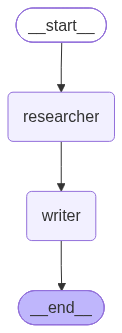

In [20]:
# Build graph of agents
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)

# Define flow
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)
final_workflow=workflow.compile()

## print final_workflow
final_workflow


### invoke graph

In [21]:
response = final_workflow.invoke({
    "messages": [HumanMessage(content="Research use case of agentic ai in finance.")]
})

In [31]:
response["messages"][-1]

AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 85, 'total_tokens': 86, 'completion_time': 0.003874439, 'completion_tokens_details': None, 'prompt_time': 0.006215676, 'prompt_tokens_details': None, 'queue_time': None, 'total_time': 0.010090115}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0075c-8c76-7aa1-93a5-1272738b59cd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 85, 'output_tokens': 1, 'total_tokens': 86})

### Summary
- The problem with the simple multi agent is there is not iterative loop. The writer can't go back to the researcher and iterate. 
- This is why we will move on to a more advanced use case where we have more dynamic flexibility.

# Supervise Multi AI Agent Architecture
- This architecture now will have directed acyclic supervised workflows with dynamic iteration built in.

In [32]:
## imports 
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

### Create Supervisor State

In [33]:
## Create the State definition for the multi-agent system
class SupervisorState(MessagesState):
    """State for the supervisor multi-agent system."""
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""

### Create Supervisor Chain

In [34]:
## Supervisor with Groq LLM
from langchain_core.prompts import ChatPromptTemplate
def create_supervisor_chain():
    """Creates the supervisor decision chain."""

    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:
        
1. Researcher - Gathers information and data
2. Analyst - Analyzes and provides insights
3. Writer - Creates reports and summaries.

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'. 

Current state: 
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
"""),
        ("human", "{task}")
    ])

    
    return supervisor_prompt | llm

In [35]:
## 2. Supervisor Agent
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using GROQ LLM."""

    messages = state["messages"]
    # Keep the ORIGINAL task -- messages[-1] drifts to the last agent's message
    task = state.get("current_task") or (messages[0].content if messages else "No task")

    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))

    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report,
        })

    # Parse decision
    decision_text = decision.content.strip().lower()
    print(decision_text)

    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = "Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "Supervisor: Research is done. Assigning to Analyst for analysis..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg = "Supervisor: Task seems complete."

    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task,
    }

In [36]:
## 1. Researcher Agent using Groq LLM
def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information."""

    task = state.get("current_task", "research topic")

    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}.

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies

    Be concise but thorough. Provide references if possible."""

    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content

    ## Create agent message 
    agent_message = f"Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."  # Limit to first 500 characters 

    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor",
    }

In [37]:
## Agent 2 -- Analyst Agent using Groq LLM
def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze research data."""

    research_data = state.get("research_data", "")
    task = state.get("current_task", "research topic")

    # Create analysis prompt
    analysis_prompt = f"""As an analyst, review the following research data on '{task}' and provide insights:

    Research data:
    {research_data}

    Provide:
    1. Key insights and patterns
    2. Strategic implications
    3. Risks and opportunities
    4. Recommendations

    Focus on actionable insights related to: {task}"""

    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content

    ## Create agent message
    agent_message = f"Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:500]}..."

    return {
            "messages": [AIMessage(content=agent_message)],
            "analysis": analysis,
            "next_agent": "supervisor",
        }

In [38]:
## 3. Writer agent (using Groq LLM)
from langgraph.func import task


def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report."""

    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")

    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

Task: {task}

Research Findings:
{research_data[:1000]}  # Limit to first 1000 characters

Analysis:
{analysis[:1000]}  # Limit to first 1000 characters

Create a well-structured report with:
1. Executive Summary
2. Key Findings
3. Analysis & Insights
4. Recommendations
5. Conclusion

Keep it professional and concise.
"""
    # Get report from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content

    # Create final formatted report
    final_report = f"""
    FINAL REPORT
{'='*50}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Topic: {task}
{'='*50}

{report}

{'='*50}
Report compiled by Multi-Agent System powered by Groq LLM.
"""
    return {
        "messages": [AIMessage(content=f"Writer: I've completed the final report.\n\n{final_report}")],
        "final_report": final_report,
        "next_agent": "supervisor",
    }

## Router Function

In [39]:
## build router function
def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state."""

    next_agent = state.get("next_agent", "supervisor")

    if next_agent == "end" or state.get("task_complete", False):
        return END

    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent 

    return "supervisor"

## Create Workflow Graph

In [40]:
## create worklow
workflow = StateGraph(SupervisorState)

## Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

## Set entry point
workflow.set_entry_point("supervisor")

## Add routing
for node in ["supervisor","researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END
        }

    )
## compile graph
graph = workflow.compile()

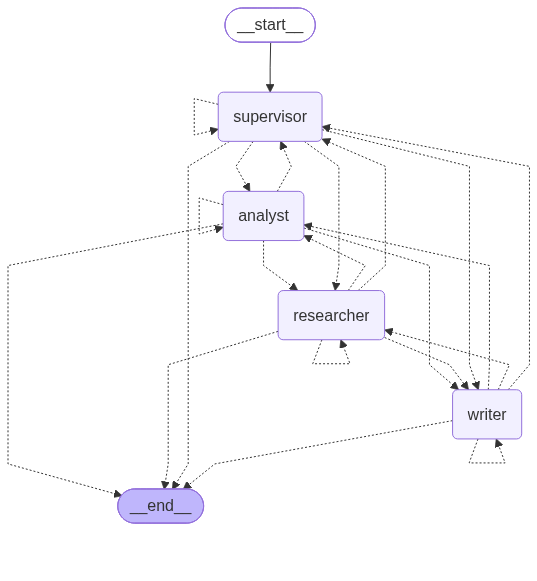

In [41]:
## display graph
graph

### invoke graph

In [42]:
## invoke the graph
result = graph.invoke({
    "messages": [HumanMessage(content="What are the benefits and risks of using AI in healthcare?")]
})
print(result["final_report"])

researcher
analyst
researcher
researcher
researcher
researcher
analyst
analyst
writer
based on the current state, the next step would be to finalize the report with the information already gathered, analyzed, and written. 

writer

    FINAL REPORT
Generated: 2026-08-15 17:41
Topic: What are the benefits and risks of using AI in healthcare?

**Executive Report: Benefits and Risks of Using AI in Healthcare**

**Executive Summary**

Artificial Intelligence (AI) is transforming the healthcare industry by improving diagnosis accuracy, enhancing patient engagement, and streamlining clinical workflows. Our research highlights the benefits and risks of using AI in healthcare, underscoring the need for strategic investment in high-quality data and careful consideration of regulatory frameworks. This report provides key findings, analysis, insights, recommendations, and a conclusion to inform healthcare organizations' AI adoption strategies.

**Key Findings**

1. **Improved diagnosis accuracy**

In [43]:
## result of graph outputs
result

{'messages': [HumanMessage(content='What are the benefits and risks of using AI in healthcare?', additional_kwargs={}, response_metadata={}, id='c03bbfef-4aba-48c6-93a0-ab53d4113e86'),
  AIMessage(content="Supervisor: Let's start with research. Assigning to Researcher...", additional_kwargs={}, response_metadata={}, id='86d279b0-9a0d-421f-8ce6-28fc3064d79d', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="Researcher: I've completed the research on 'What are the benefits and risks of using AI in healthcare?'.\n\nKey findings:\n**Benefits and Risks of Using AI in Healthcare**\n\n**Key Facts and Background:**\n\nArtificial Intelligence (AI) in healthcare refers to the application of machine learning, natural language processing, and other AI technologies to improve healthcare outcomes, efficiency, and patient experience. AI can analyze vast amounts of medical data, identify patterns, and make predictions, enabling healthcare professionals to make more informed decisions.\n\n**

# Simple Hierarchical Multi-Agent System

## Design

We reuse the existing `researcher_agent`, `analyst_agent`, `writer_agent`, and `SupervisorState` from the supervisor section above, but instead of one flat supervisor routing between all three agents, we group them into **teams** and compile each team as its own subgraph. Each compiled team subgraph is then plugged into a top-level graph as a single node — this nesting is what makes the system "hierarchical."

- **Research Team** (subgraph): `researcher` → `analyst` → END
- **Writing Team** (subgraph): `writer` → END
- **Top-level graph**: `research_team` → `writing_team` → END

Because the top-level graph never routes back to an earlier node, it's a true DAG (unlike the supervisor graph above, which cycles back through `supervisor` after every agent runs). The top graph only "knows about" two team nodes; each team internally manages its own agents and state updates (`research_data`, `analysis`, `final_report`).

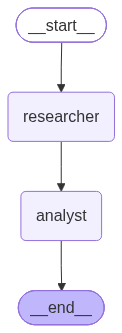

In [44]:
## Research Team subgraph: researcher -> analyst -> END
research_team_builder = StateGraph(SupervisorState)
research_team_builder.add_node("researcher", researcher_agent)
research_team_builder.add_node("analyst", analyst_agent)

research_team_builder.set_entry_point("researcher")
research_team_builder.add_edge("researcher", "analyst")
research_team_builder.add_edge("analyst", END)

research_team = research_team_builder.compile()
research_team

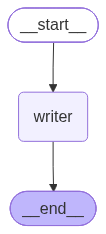

In [45]:
## Writing Team subgraph: writer -> END
writing_team_builder = StateGraph(SupervisorState)
writing_team_builder.add_node("writer", writer_agent)

writing_team_builder.set_entry_point("writer")
writing_team_builder.add_edge("writer", END)

writing_team = writing_team_builder.compile()
writing_team

### Compose the Top-Level Hierarchical DAG

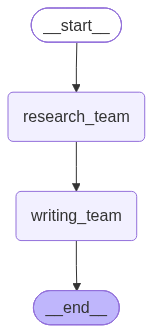

In [46]:
## Top-level graph: wires the two compiled team subgraphs together as nodes
hierarchical_builder = StateGraph(SupervisorState)

hierarchical_builder.add_node("research_team", research_team)
hierarchical_builder.add_node("writing_team", writing_team)

hierarchical_builder.set_entry_point("research_team")
hierarchical_builder.add_edge("research_team", "writing_team")
hierarchical_builder.add_edge("writing_team", END)

hierarchical_graph = hierarchical_builder.compile()
hierarchical_graph

### Visualize the DAG
Note the graph structure is strictly forward — no edges point back to `research_team` once `writing_team` runs.

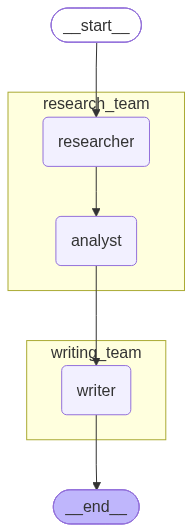

In [47]:
## visualize the hierarchical graph structure (xray=True expands the team subgraphs)
from IPython.display import Image, display
display(Image(hierarchical_graph.get_graph(xray=True).draw_mermaid_png()))

### Invoke and Test the Hierarchical Graph
`current_task` is passed explicitly here since the team agents read it via `state.get("current_task", ...)` rather than deriving it from `messages` (that fallback only exists in `supervisor_agent`).

In [48]:
## test the hierarchical multi-agent system
task = "What are the benefits and risks of using AI in supply chain management?"

hierarchical_result = hierarchical_graph.invoke({
    "messages": [HumanMessage(content=task)],
    "current_task": task,
})

print(hierarchical_result["final_report"])


    FINAL REPORT
Generated: 2026-08-15 17:42
Topic: What are the benefits and risks of using AI in supply chain management?

**Executive Report: Benefits and Risks of Using AI in Supply Chain Management**

**Executive Summary**

As the supply chain landscape continues to evolve, the adoption of Artificial Intelligence (AI) in Supply Chain Management (SCM) is growing rapidly. This report highlights the benefits and risks of using AI in SCM, drawing on research findings that demonstrate improved forecasting, enhanced visibility, increased efficiency, better inventory management, and enhanced customer experience. The report also identifies key patterns and insights, including increased adoption, improved efficiency and productivity, and integration with other technologies.

**Key Findings**

Our research reveals the following key benefits and risks of using AI in SCM:

**Benefits:**

1. **Improved Forecasting:** AI can analyze historical data and real-time market trends to predict demand

In [49]:
## sanity checks: confirm both teams actually ran and populated state
assert hierarchical_result.get("research_data"), "research_team did not produce research_data"
assert hierarchical_result.get("analysis"), "research_team did not produce analysis"
assert hierarchical_result.get("final_report"), "writing_team did not produce final_report"

## inspect the message trail produced by each team, in order
for m in hierarchical_result["messages"]:
    label = getattr(m, "type", m.__class__.__name__)
    print(f"[{label}] {m.content[:200]}\n")

[human] What are the benefits and risks of using AI in supply chain management?

[ai] Researcher: I've completed the research on 'What are the benefits and risks of using AI in supply chain management?'.

Key findings:
**Key Facts and Background:**

Artificial Intelligence (AI) is incr

[ai] Analyst: I've completed the analysis.

Top insights:
**Key Insights and Patterns:**

1. **Increased Adoption:** The research indicates a growing trend of adopting AI-powered SCM solutions, with 73% of

[ai] Writer: I've completed the final report.


    FINAL REPORT
Generated: 2026-08-15 17:42
Topic: What are the benefits and risks of using AI in supply 

